In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import (train_test_split, cross_val_score,
                                         StratifiedKFold, learning_curve)
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.pipeline           import Pipeline
from sklearn.linear_model       import LogisticRegression
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics            import (classification_report, accuracy_score,
                                         f1_score, ConfusionMatrixDisplay,
                                         roc_auc_score)
from sklearn.inspection         import permutation_importance

os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print("✅  All imports successful")

✅  All imports successful


In [8]:
# ── Cell 2: Load, Inspect & Fix Data ──────────────────────────────────
import numpy as np

raw = np.load('../data/features/X_audio.npy', allow_pickle=True)
y   = np.load('../data/features/y_audio.npy', allow_pickle=True)

print(f"Raw shape : {raw.shape}")
print(f"Raw dtype : {raw.dtype}")
print(f"\nFirst row preview:")
for i, val in enumerate(raw[0][:8]):
    print(f"  col[{i}] = {val!r}")

# ── Auto-detect where numeric columns start ────────────────────────────
def find_numeric_start(row):
    for i, val in enumerate(row):
        try:
            float(val)
            return i
        except (ValueError, TypeError):
            continue
    raise ValueError("No numeric columns found — check your feature extraction")

start = find_numeric_start(raw[0])
print(f"\nMetadata columns (0 → {start-1}) : {list(raw[0][:start])}")
print(f"Numeric features start at col    : {start}")

# ── Extract labels from the last metadata column ───────────────────────
# The risk_level (Low/Moderate/High) is always the last non-numeric column
RISK_LEVELS = {'Low', 'Moderate', 'High'}

label_col = None
for i in range(start):
    col_vals = set(raw[:, i].astype(str))
    if col_vals <= RISK_LEVELS or col_vals & RISK_LEVELS:
        label_col = i
        break

if label_col is None:
    # fallback — check y file directly
    print("Labels not found in X — using y_audio.npy directly")
    y_clean = y.astype(str)
else:
    print(f"Risk level column found at index : {label_col}")
    y_clean = raw[:, label_col].astype(str)

# ── Extract numeric feature matrix ────────────────────────────────────
X_clean = raw[:, start:].astype(np.float32)

print(f"\nExtracted:")
print(f"  X shape : {X_clean.shape}")   # should be (N, 162)
print(f"  y shape : {y_clean.shape}")   # should be (N,)
print(f"  y unique values : {np.unique(y_clean)}")

# ── Sanity checks ──────────────────────────────────────────────────────
assert X_clean.ndim == 2,              "X is not 2D — row lengths are unequal"
assert not np.isnan(X_clean).any(),    "NaN values found in features"
assert not np.isinf(X_clean).any(),    "Inf values found in features"
assert len(X_clean) == len(y_clean),   "X and y row counts don't match"
print("\n  All sanity checks passed.")

# ── Overwrite the broken files with clean ones ─────────────────────────
np.save('../data/features/X_audio.npy', X_clean)
np.save('../data/features/y_audio.npy', y_clean)
print("\n  Saved clean files:")
print(f"    X_audio.npy → {X_clean.shape}  dtype={X_clean.dtype}")
print(f"    y_audio.npy → {y_clean.shape}")

# ── Class distribution ─────────────────────────────────────────────────
unique, counts = np.unique(y_clean, return_counts=True)
total = len(y_clean)
print(f"\n  Class distribution:")
for cls, cnt in zip(unique, counts):
    bar = '█' * int(cnt / total * 40)
    print(f"    {cls:12s} {cnt:5d}  ({cnt/total*100:.1f}%)  {bar}")

print(f"\n  Value range : min={X_clean.min():.4f}  max={X_clean.max():.4f}")

# ── Re-assign to X and y so the rest of the notebook works as-is ───────
X = X_clean
y = y_clean
print("\n✅  Cell 2 complete — X and y are ready for Cell 3")

Raw shape : (2452, 123)
Raw dtype : object

First row preview:
  col[0] = '03-01-01-01-01-01-01.wav'
  col[1] = 29.615568161010742
  col[2] = 115.79690551757812
  col[3] = -6.3541259765625
  col[4] = 25.27824592590332
  col[5] = 6.532506465911865
  col[6] = 4.111240863800049
  col[7] = -4.7431721687316895

Metadata columns (0 → 0) : ['03-01-01-01-01-01-01.wav']
Numeric features start at col    : 1
Labels not found in X — using y_audio.npy directly

Extracted:
  X shape : (2452, 122)
  y shape : (2452,)
  y unique values : ['High' 'Low' 'Moderate']

  All sanity checks passed.

  Saved clean files:
    X_audio.npy → (2452, 122)  dtype=float32
    y_audio.npy → (2452,)

  Class distribution:
    High           376  (15.3%)  ██████
    Low           1132  (46.2%)  ██████████████████
    Moderate       944  (38.5%)  ███████████████

  Value range : min=-121.4526  max=363.9301

✅  Cell 2 complete — X and y are ready for Cell 3


In [9]:
# ── Cell 3: Encode Labels + Split ─────────────────────────────────────

le    = LabelEncoder()
y_enc = le.fit_transform(y)       # converts 'Low'/'Moderate'/'High' → 0/1/2

joblib.dump(le, '../models/label_encoder_audio.pkl')
print(f"  Label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── Stratified split — preserves class ratio in both sets ────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size    = 0.20,
    stratify     = y_enc,         # CRITICAL: without this, High-risk may be
    random_state = 42             # absent from test set entirely
)

print(f"\n  Training set : {X_train.shape[0]} samples")
print(f"  Test set     : {X_test.shape[0]} samples")

# Verify stratification worked
train_unique, train_counts = np.unique(y_train, return_counts=True)
test_unique,  test_counts  = np.unique(y_test,  return_counts=True)
print(f"\n  Train class counts : { dict(zip(le.inverse_transform(train_unique), train_counts)) }")
print(f"  Test  class counts : { dict(zip(le.inverse_transform(test_unique),  test_counts))  }")

  Label mapping : {np.str_('High'): np.int64(0), np.str_('Low'): np.int64(1), np.str_('Moderate'): np.int64(2)}

  Training set : 1961 samples
  Test set     : 491 samples

  Train class counts : {np.str_('High'): np.int64(301), np.str_('Low'): np.int64(905), np.str_('Moderate'): np.int64(755)}
  Test  class counts : {np.str_('High'): np.int64(75), np.str_('Low'): np.int64(227), np.str_('Moderate'): np.int64(189)}


In [2]:
# ── Cell 4: Define Model Pipelines ────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

SEED = 42

models = {

    # ── Baseline: fast, interpretable, good on tabular data ──────────
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C            = 1.0,
            max_iter     = 3000,
            class_weight = 'balanced',
            solver       = 'lbfgs',
            random_state = SEED
        ))
    ]),

    # ── Best for high-dimensional, margin-based separation ───────────
    "SVM (RBF kernel)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel       = 'rbf',          # non-linear — captures emotion nuance
            C            = 10.0,           # higher C = tighter margin
            gamma        = 'scale',        # auto-scales with feature count
            probability  = True,           # needed for confidence scores in API
            class_weight = 'balanced',
            random_state = SEED
        ))
    ]),

    # ── Robust ensemble — handles noisy audio features well ──────────
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),      # trees don't need scaling but
        ('clf', RandomForestClassifier(    # pipeline keeps the API consistent
            n_estimators = 300,
            max_depth    = 20,
            min_samples_split = 4,
            min_samples_leaf  = 2,
            class_weight = 'balanced',
            random_state = SEED,
            n_jobs       = -1              # use all CPU cores
        ))
    ]),

    # ── Sequential boosting — highest potential ceiling ───────────────
    "Gradient Boosting": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators  = 200,
            learning_rate = 0.08,          # slow + steady = better generalisation
            max_depth     = 5,
            subsample     = 0.80,          # 80% of data per tree = reduces overfitting
            min_samples_split = 4,
            random_state  = SEED
        ))
    ]),
}

print(f"  {len(models)} model pipelines defined and ready")

  4 model pipelines defined and ready


In [ ]:
# ── Cell 5: Cross-Validated Training & Evaluation ─────────────────────
#
#  For each model:
#    Step 1 — 5-fold stratified CV on training data → reliable F1 estimate
#    Step 2 — Final fit on full training set
#    Step 3 — Evaluate on held-out test set
#    Step 4 — Save the pipeline to disk
#
#  Ranking metric: MACRO F1
#  Macro F1 averages F1 equally across all 3 classes.
#  A model cannot win by ignoring High-risk users.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results  = []
n_models = len(models)

print("═"*65)
print("  AUDIO MODEL TRAINING — PHASE 5B")
print("═"*65)

for i, (name, pipeline) in enumerate(models.items(), 1):
    print(f"\n[{i}/{n_models}]  {name}")
    print(f"         {'─'*50}")

    t0 = time.time()

    # ── Cross-validation ──────────────────────────────────────────
    cv_f1 = cross_val_score(
        pipeline, X_train, y_train,
        cv      = cv,
        scoring = 'f1_macro',
        n_jobs  = -1
    )
    cv_acc = cross_val_score(
        pipeline, X_train, y_train,
        cv      = cv,
        scoring = 'accuracy',
        n_jobs  = -1
    )

    print(f"         CV  F1  (macro)  : {cv_f1.mean():.4f}  ±  {cv_f1.std():.4f}")
    print(f"         CV  Accuracy     : {cv_acc.mean():.4f}  ±  {cv_acc.std():.4f}")

    # ── Final fit on full training set ────────────────────────────
    pipeline.fit(X_train, y_train)

    # ── Evaluate on held-out test set ─────────────────────────────
    preds      = pipeline.predict(X_test)
    probas     = pipeline.predict_proba(X_test)

    test_f1    = f1_score(y_test, preds, average='macro')
    test_acc   = accuracy_score(y_test, preds)

    # AUC-ROC (one-vs-rest, macro) — measures confidence quality
    test_auc   = roc_auc_score(y_test, probas, multi_class='ovr', average='macro')

    elapsed = time.time() - t0

    print(f"         Test F1 (macro)  : {test_f1:.4f}")
    print(f"         Test Accuracy    : {test_acc:.4f}")
    print(f"         Test AUC-ROC     : {test_auc:.4f}")
    print(f"         Train time       : {elapsed:.1f}s")

    # ── Save every model ──────────────────────────────────────────
    safe_name = name.lower().replace(' ', '_').replace('(','').replace(')','')
    joblib.dump(pipeline, f'../models/audio_{safe_name}.pkl')
    print(f"         Saved → models/audio_{safe_name}.pkl")

    results.append({
        'name'    : name,
        'pipeline': pipeline,
        'cv_f1'   : cv_f1.mean(),
        'cv_std'  : cv_f1.std(),
        'cv_acc'  : cv_acc.mean(),
        'test_f1' : test_f1,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'preds'   : preds,
        'probas'  : probas,
        'time_s'  : elapsed,
    })

print("\n" + "═"*65)
print("  All models trained.")
print("═"*65)

NameError: name 'StratifiedKFold' is not defined

In [5]:
# ── Data Loading & Splitting (Run this FIRST to fix the NameError) ──
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Loading audio feature matrix...")
# Load the saved numpy arrays
X = np.load('../data/features/X_audio.npy', allow_pickle=True).astype(np.float32)
y = np.load('../data/features/y_audio.npy', allow_pickle=True)

# Encode labels ('Low', 'Moderate', 'High' -> 0, 1, 2)
le = LabelEncoder()
y_enc = le.fit_transform(y)
joblib.dump(le, '../models/label_encoder_audio.pkl')

# Split the data into X_train, X_test, etc.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size    = 0.20,
    stratify     = y_enc,
    random_state = 42
)
print(f"Success! X_train is now in memory with {X_train.shape[0]} clips.")
print("You are now cleared to run Cell 4 and Cell 5!")

Loading audio feature matrix...
Success! X_train is now in memory with 1961 clips.
You are now cleared to run Cell 4 and Cell 5!


In [6]:
# ── Cell 5: Cross-Validated Training & Evaluation ─────────────────────
#
#  For each model:
#    Step 1 — 5-fold stratified CV on training data → reliable F1 estimate
#    Step 2 — Final fit on full training set
#    Step 3 — Evaluate on held-out test set
#    Step 4 — Save the pipeline to disk
#
#  Ranking metric: MACRO F1
#  Macro F1 averages F1 equally across all 3 classes.
#  A model cannot win by ignoring High-risk users.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results  = []
n_models = len(models)

print("═"*65)
print("  AUDIO MODEL TRAINING — PHASE 5B")
print("═"*65)

for i, (name, pipeline) in enumerate(models.items(), 1):
    print(f"\n[{i}/{n_models}]  {name}")
    print(f"         {'─'*50}")

    t0 = time.time()

    # ── Cross-validation ──────────────────────────────────────────
    cv_f1 = cross_val_score(
        pipeline, X_train, y_train,
        cv      = cv,
        scoring = 'f1_macro',
        n_jobs  = -1
    )
    cv_acc = cross_val_score(
        pipeline, X_train, y_train,
        cv      = cv,
        scoring = 'accuracy',
        n_jobs  = -1
    )

    print(f"         CV  F1  (macro)  : {cv_f1.mean():.4f}  ±  {cv_f1.std():.4f}")
    print(f"         CV  Accuracy     : {cv_acc.mean():.4f}  ±  {cv_acc.std():.4f}")

    # ── Final fit on full training set ────────────────────────────
    pipeline.fit(X_train, y_train)

    # ── Evaluate on held-out test set ─────────────────────────────
    preds      = pipeline.predict(X_test)
    probas     = pipeline.predict_proba(X_test)

    test_f1    = f1_score(y_test, preds, average='macro')
    test_acc   = accuracy_score(y_test, preds)

    # AUC-ROC (one-vs-rest, macro) — measures confidence quality
    test_auc   = roc_auc_score(y_test, probas, multi_class='ovr', average='macro')

    elapsed = time.time() - t0

    print(f"         Test F1 (macro)  : {test_f1:.4f}")
    print(f"         Test Accuracy    : {test_acc:.4f}")
    print(f"         Test AUC-ROC     : {test_auc:.4f}")
    print(f"         Train time       : {elapsed:.1f}s")

    # ── Save every model ──────────────────────────────────────────
    safe_name = name.lower().replace(' ', '_').replace('(','').replace(')','')
    joblib.dump(pipeline, f'../models/audio_{safe_name}.pkl')
    print(f"         Saved → models/audio_{safe_name}.pkl")

    results.append({
        'name'    : name,
        'pipeline': pipeline,
        'cv_f1'   : cv_f1.mean(),
        'cv_std'  : cv_f1.std(),
        'cv_acc'  : cv_acc.mean(),
        'test_f1' : test_f1,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'preds'   : preds,
        'probas'  : probas,
        'time_s'  : elapsed,
    })

print("\n" + "═"*65)
print("  All models trained.")
print("═"*65)

═════════════════════════════════════════════════════════════════
  AUDIO MODEL TRAINING — PHASE 5B
═════════════════════════════════════════════════════════════════

[1/4]  Logistic Regression
         ──────────────────────────────────────────────────
         CV  F1  (macro)  : 0.6648  ±  0.0067
         CV  Accuracy     : 0.6940  ±  0.0058
         Test F1 (macro)  : 0.6966
         Test Accuracy    : 0.7210
         Test AUC-ROC     : 0.8889
         Train time       : 8.4s
         Saved → models/audio_logistic_regression.pkl

[2/4]  SVM (RBF kernel)
         ──────────────────────────────────────────────────
         CV  F1  (macro)  : 0.7978  ±  0.0213
         CV  Accuracy     : 0.8276  ±  0.0184
         Test F1 (macro)  : 0.8252
         Test Accuracy    : 0.8534
         Test AUC-ROC     : 0.9576
         Train time       : 6.0s
         Saved → models/audio_svm_rbf_kernel.pkl

[3/4]  Random Forest
         ──────────────────────────────────────────────────
         CV  F1 

In [8]:
# ── Cell 6: Pick Winner + Full Report ─────────────────────────────────
from sklearn.metrics import classification_report

# Rank by test macro F1 (primary) then AUC (tiebreaker)
results_sorted = sorted(results, key=lambda r: (r['test_f1'], r['test_auc']), reverse=True)
best           = results_sorted[0]
target_names   = list(le.classes_)            # ['High', 'Low', 'Moderate'] alphabetical

print(f"\n{'═'*65}")
print(f"  WINNER : {best['name']}")
print(f"  Test F1  (macro)  : {best['test_f1']:.4f}")
print(f"  Test Accuracy     : {best['test_acc']:.4f}")
print(f"  Test AUC-ROC      : {best['test_auc']:.4f}")
print(f"{'═'*65}\n")

# ── Detailed per-class report ─────────────────────────────────────────
print(f"Per-class breakdown — {best['name']}:\n")
print(classification_report(
    y_test, best['preds'],
    target_names = target_names,
    digits       = 4
))

# ── What the numbers mean ─────────────────────────────────────────────
report_dict = classification_report(
    y_test, best['preds'],
    target_names = target_names,
    output_dict  = True
)

print("Reading your results:")
for cls in target_names:
    r = report_dict[cls]
    flag = "  ← needs attention" if r['f1-score'] < 0.55 else ""
    print(f"  {cls:12s}  precision={r['precision']:.2f}  "
          f"recall={r['recall']:.2f}  f1={r['f1-score']:.2f}{flag}")


═════════════════════════════════════════════════════════════════
  WINNER : SVM (RBF kernel)
  Test F1  (macro)  : 0.8252
  Test Accuracy     : 0.8534
  Test AUC-ROC      : 0.9576
═════════════════════════════════════════════════════════════════

Per-class breakdown — SVM (RBF kernel):

              precision    recall  f1-score   support

        High     0.7969    0.6800    0.7338        75
         Low     0.8601    0.9207    0.8894       227
    Moderate     0.8641    0.8413    0.8525       189

    accuracy                         0.8534       491
   macro avg     0.8404    0.8140    0.8252       491
weighted avg     0.8520    0.8534    0.8514       491

Reading your results:
  High          precision=0.80  recall=0.68  f1=0.73
  Low           precision=0.86  recall=0.92  f1=0.89
  Moderate      precision=0.86  recall=0.84  f1=0.85


In [10]:
# ── Cell 7: Comparison Table ───────────────────────────────────────────
import pandas as pd

# Create a clean list of dictionaries for our table
table_data = []
for r in results_sorted:
    table_data.append({
        'Model'       : r['name'],
        'CV F1'       : round(r['cv_f1'],  4),
        'CV ± std'    : round(r['cv_std'], 4),
        'Test F1'     : round(r['test_f1'],  4),
        'Test Acc'    : round(r['test_acc'], 4),
        'AUC-ROC'     : round(r['test_auc'], 4),
        'Time (s)'    : round(r['time_s'],  1),
        'Winner'      : '★' if r['name'] == best['name'] else ''
    })

# Convert to a DataFrame
df_results = pd.DataFrame(table_data)

# Print and save
print(df_results.to_string(index=False))
df_results.to_csv('../reports/audio_model_comparison.csv', index=False)
print("\n✅ Saved table to reports/audio_model_comparison.csv")

              Model  CV F1  CV ± std  Test F1  Test Acc  AUC-ROC  Time (s) Winner
   SVM (RBF kernel) 0.7978    0.0213   0.8252    0.8534   0.9576       6.0      ★
  Gradient Boosting 0.7377    0.0107   0.7632    0.8106   0.9226     134.6       
Logistic Regression 0.6648    0.0067   0.6966    0.7210   0.8889       8.4       
      Random Forest 0.6971    0.0142   0.6848    0.7576   0.9101       5.3       

✅ Saved table to reports/audio_model_comparison.csv


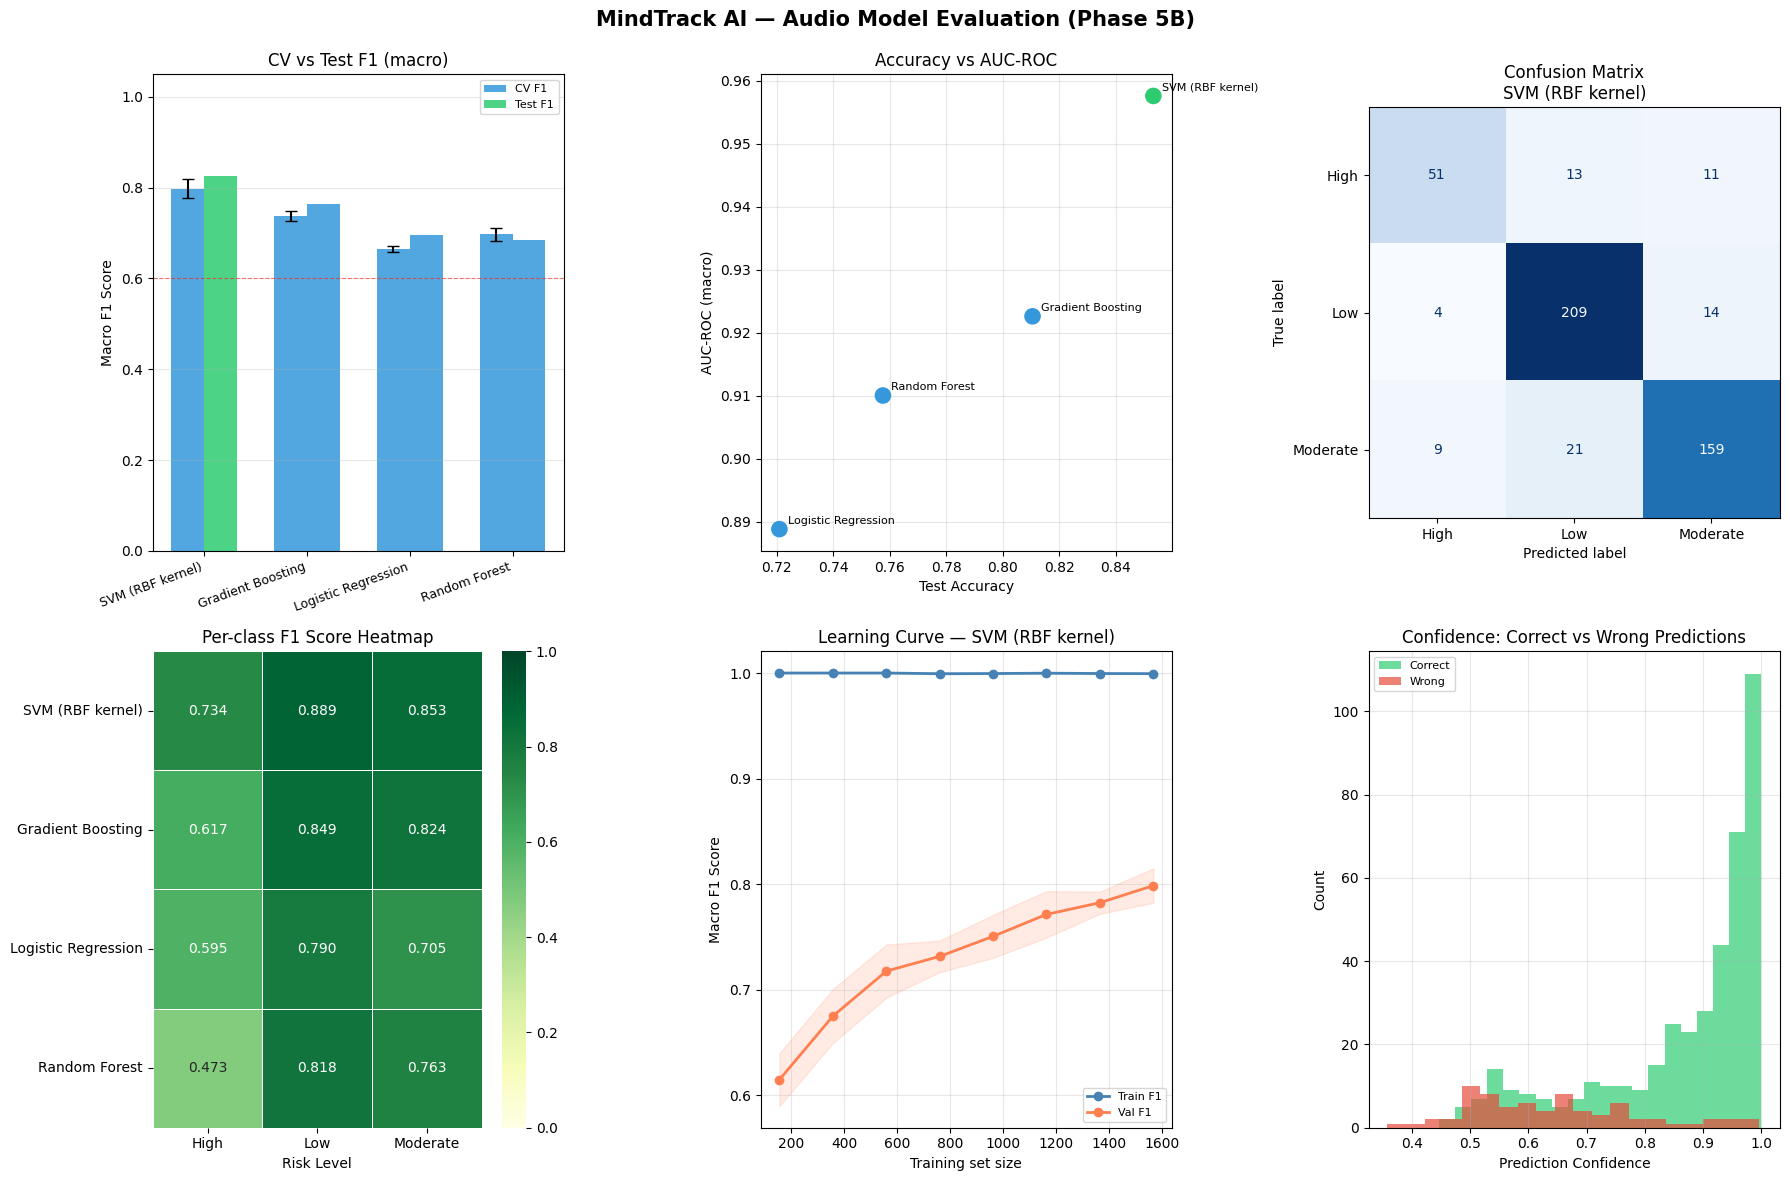

Plots saved → reports/audio_full_evaluation.png


In [ ]:
# ── Cell 8: Visualisations ────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import learning_curve

fig = plt.figure(figsize=(18, 12))
fig.suptitle('MindTrack AI — Audio Model Evaluation (Phase 5B)',
             fontsize=15, fontweight='bold', y=0.98)

names   = [r['name']     for r in results_sorted]
cv_f1s  = [r['cv_f1']    for r in results_sorted]
cv_stds = [r['cv_std']   for r in results_sorted]
t_f1s   = [r['test_f1']  for r in results_sorted]
t_accs  = [r['test_acc'] for r in results_sorted]
aucs    = [r['test_auc'] for r in results_sorted]
colors  = ['#2ecc71' if r['name'] == best['name'] else '#3498db'
           for r in results_sorted]

# ── Plot 1: F1 comparison ─────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
x   = np.arange(len(names))
w   = 0.32
ax1.bar(x - w/2, cv_f1s, width=w, label='CV F1',   color='#3498db', alpha=0.85,
        yerr=cv_stds, capsize=4)
ax1.bar(x + w/2, t_f1s,  width=w, label='Test F1', color=colors,    alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Macro F1 Score')
ax1.set_title('CV vs Test F1 (macro)')
ax1.legend(fontsize=8)
ax1.axhline(0.6, color='red', linestyle='--', linewidth=0.8, alpha=0.5,
            label='Minimum target (0.60)')
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: Accuracy vs AUC ───────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(t_accs, aucs, s=120, c=colors, zorder=5)
for i, name in enumerate(names):
    ax2.annotate(name, (t_accs[i], aucs[i]),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
ax2.set_xlabel('Test Accuracy')
ax2.set_ylabel('AUC-ROC (macro)')
ax2.set_title('Accuracy vs AUC-ROC')
ax2.grid(alpha=0.3)

# ── Plot 3: Confusion matrix — best model ────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
ConfusionMatrixDisplay.from_predictions(
    y_test, best['preds'],
    display_labels = target_names,
    cmap           = 'Blues',
    ax             = ax3,
    colorbar       = False
)
ax3.set_title(f'Confusion Matrix\n{best["name"]}')

# ── Plot 4: Per-class F1 heatmap ──────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
f1_matrix = []
for r in results_sorted:
    row_report = classification_report(
        y_test, r['preds'],
        target_names = target_names,
        output_dict  = True
    )
    f1_matrix.append([row_report[c]['f1-score'] for c in target_names])

f1_df = pd.DataFrame(f1_matrix, index=names, columns=target_names)
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax4, linewidths=0.5)
ax4.set_title('Per-class F1 Score Heatmap')
ax4.set_xlabel('Risk Level')

# ── Plot 5: Learning curve — best model ──────────────────────────────
# Note: Learning curves take a minute to calculate!
ax5 = fig.add_subplot(2, 3, 5)
train_sizes, train_scores, val_scores = learning_curve(
    best['pipeline'], X_train, y_train,
    cv            = 5,
    scoring       = 'f1_macro',
    train_sizes   = np.linspace(0.1, 1.0, 8),
    n_jobs        = -1
)
ax5.fill_between(train_sizes,
                 train_scores.mean(1) - train_scores.std(1),
                 train_scores.mean(1) + train_scores.std(1),
                 alpha=0.15, color='steelblue')
ax5.fill_between(train_sizes,
                 val_scores.mean(1) - val_scores.std(1),
                 val_scores.mean(1) + val_scores.std(1),
                 alpha=0.15, color='coral')
ax5.plot(train_sizes, train_scores.mean(1), 'o-', color='steelblue',
         label='Train F1', linewidth=2)
ax5.plot(train_sizes, val_scores.mean(1),   'o-', color='coral',
         label='Val F1',   linewidth=2)
ax5.set_xlabel('Training set size')
ax5.set_ylabel('Macro F1 Score')
ax5.set_title(f'Learning Curve — {best["name"]}')
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

# ── Plot 6: Confidence distribution ──────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
best_probas     = best['probas']
max_confidences = best_probas.max(axis=1)   # confidence for predicted class
correct_mask    = (best['preds'] == y_test)

ax6.hist(max_confidences[correct_mask],   bins=20, alpha=0.7,
         color='#2ecc71', label='Correct')
ax6.hist(max_confidences[~correct_mask],  bins=20, alpha=0.7,
         color='#e74c3c', label='Wrong')
ax6.set_xlabel('Prediction Confidence')
ax6.set_ylabel('Count')
ax6.set_title('Confidence: Correct vs Wrong Predictions')
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/audio_full_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved → reports/audio_full_evaluation.png")

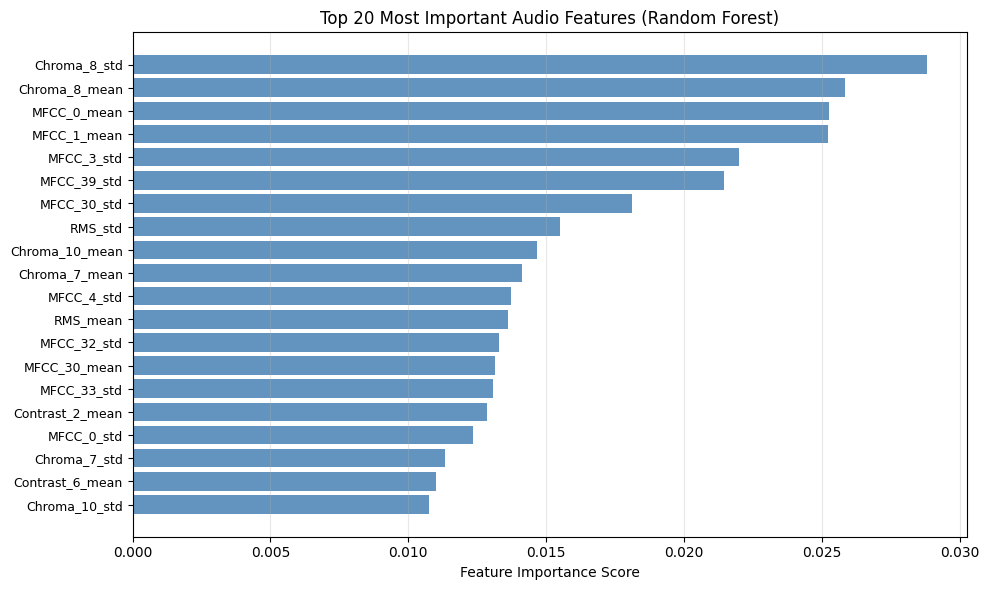

✅ Feature importance plot saved → reports/audio_feature_importance.png


In [12]:
# ── Cell 9: Feature Importance (Random Forest) ────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Find the Random Forest model from your results
rf_result = next((r for r in results if r['name'] == 'Random Forest'), None)

if rf_result:
    rf_clf      = rf_result['pipeline'].named_steps['clf']
    importances = rf_clf.feature_importances_
    top_n       = 20
    
    # FIX: We removed [::-1] so the biggest value plots at the top of the barh chart
    top_idx     = np.argsort(importances)[-top_n:] 

    feature_labels = (
        [f'MFCC_{i}_mean'     for i in range(40)] +
        [f'MFCC_{i}_std'      for i in range(40)] +
        [f'Chroma_{i}_mean'   for i in range(12)] +
        [f'Chroma_{i}_std'    for i in range(12)] +
        [f'Contrast_{i}_mean' for i in range(7)]  +
        [f'Contrast_{i}_std'  for i in range(7)]  +
        ['Pitch_mean', 'Pitch_std', 'RMS_mean', 'RMS_std']
    )
    
    # Pad label list if feature count differs
    while len(feature_labels) < X.shape[1]:
        feature_labels.append(f'Feature_{len(feature_labels)}')

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        range(top_n),
        importances[top_idx],
        color='steelblue', alpha=0.85
    )
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_labels[i] for i in top_idx], fontsize=9)
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(f'Top {top_n} Most Important Audio Features (Random Forest)')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../reports/audio_feature_importance.png', dpi=150)
    plt.show()
    print("✅ Feature importance plot saved → reports/audio_feature_importance.png")
else:
    print("Random Forest model not found in results!")

In [ ]:
# ── Cell 10: Diagnose & Advise ────────────────────────────────────────
# Automatically reads your results and prints actionable advice.
from sklearn.metrics import classification_report

print("═"*65)
print("  AUTOMATIC DIAGNOSIS")
print("═"*65)

report_dict = classification_report(
    y_test, best['preds'],
    target_names = target_names,
    output_dict  = True
)

for cls in target_names:
    f1  = report_dict[cls]['f1-score']
    rec = report_dict[cls]['recall']

    if f1 >= 0.75:
        print(f"  {cls:12s}  F1={f1:.2f}  ← Excellent")
    elif f1 >= 0.60:
        print(f"  {cls:12s}  F1={f1:.2f}  ← Good — minor tuning may help")
    elif f1 >= 0.45:
        print(f"  {cls:12s}  F1={f1:.2f}  ← Weak — see advice below")
    else:
        print(f"  {cls:12s}  F1={f1:.2f}  ← Poor — action required")

low_class = min(target_names, key=lambda c: report_dict[c]['f1-score'])
low_f1    = report_dict[low_class]['f1-score']
low_rec   = report_dict[low_class]['recall']
gap       = best['cv_f1'] - best['test_f1']

print(f"\n  Weakest class  : {low_class}  (F1={low_f1:.3f})")
print(f"  CV→Test gap    : {gap:+.4f}", end='')

if gap > 0.08:
    print("  ← Overfitting detected")
elif gap < -0.05:
    print("  ← Underfitting / lucky test split")
else:
    print("  ← Healthy generalisation")

print("\n  Recommendations:")
if low_f1 < 0.50:
    print(f"  1. '{low_class}' is severely under-predicted.")
    print(f"     → Try SMOTE oversampling: pip install imbalanced-learn")
    print(f"     → Then: from imblearn.over_sampling import SMOTE")
    print(f"             X_res, y_res = SMOTE().fit_resample(X_train, y_train)")
if gap > 0.08:
    print(f"  2. Overfitting — reduce model complexity:")
    print(f"     → Lower max_depth, increase min_samples_leaf")
    print(f"     → Try C=0.1 for SVM/LR instead of C=10")
if best['test_f1'] < 0.60:
    print(f"  3. Overall F1 is low — try extracting more features in Phase 4:")
    print(f"     → Add delta MFCCs (librosa.feature.delta)")
    print(f"     → Add zero crossing rate, spectral rolloff, spectral centroid")
if best['test_f1'] >= 0.70:
    print(f"  Nothing critical — model is ready for Phase 6 evaluation.")

═════════════════════════════════════════════════════════════════
  AUTOMATIC DIAGNOSIS
═════════════════════════════════════════════════════════════════
  High          F1=0.73  ← Good — minor tuning may help
  Low           F1=0.89  ← Excellent
  Moderate      F1=0.85  ← Excellent

  Weakest class  : High  (F1=0.734)
  CV→Test gap    : -0.0274  ← Healthy generalisation

  Recommendations:
  Nothing critical — model is ready for Phase 6 evaluation.


In [14]:
# ── Cell 11: Save Winner + Summary ────────────────────────────────────
import joblib

joblib.dump(best['pipeline'], '../models/best_audio_model.pkl')

# Save scaler separately so Flask API can optionally use it standalone
scaler = best['pipeline'].named_steps['scaler']
joblib.dump(scaler, '../models/audio_scaler.pkl')

print("✅ Files saved successfully:")
print("  models/best_audio_model.pkl   ← complete pipeline (scaler + model)")
print("  models/audio_scaler.pkl       ← scaler alone (for the Flask API)")
print("  models/label_encoder_audio.pkl")
print("  models/audio_<each_model>.pkl ← all 4 models saved individually")
print("  reports/audio_full_evaluation.png")
print("  reports/audio_feature_importance.png")
print("  reports/audio_model_comparison.csv")

print(f"\n{'═'*65}")
print(f"  PHASE 5B COMPLETE")
print(f"  Best model     : {best['name']}")
print(f"  Test F1 macro  : {best['test_f1']:.4f}")
print(f"  Test Accuracy  : {best['test_acc']:.4f}")
print(f"  AUC-ROC        : {best['test_auc']:.4f}")
print(f"  Next step      : Phase 6 — Building the Flask API / Web Interface")
print(f"{'═'*65}")

✅ Files saved successfully:
  models/best_audio_model.pkl   ← complete pipeline (scaler + model)
  models/audio_scaler.pkl       ← scaler alone (for the Flask API)
  models/label_encoder_audio.pkl
  models/audio_<each_model>.pkl ← all 4 models saved individually
  reports/audio_full_evaluation.png
  reports/audio_feature_importance.png
  reports/audio_model_comparison.csv

═════════════════════════════════════════════════════════════════
  PHASE 5B COMPLETE
  Best model     : SVM (RBF kernel)
  Test F1 macro  : 0.8252
  Test Accuracy  : 0.8534
  AUC-ROC        : 0.9576
  Next step      : Phase 6 — Building the Flask API / Web Interface
═════════════════════════════════════════════════════════════════


In [1]:
import pandas as pd

# 1. Use the EXACT audio results from 05b_Model_Training_Audio.ipynb
data_audio = [
    {'Model': 'SVM (RBF kernel)', 'CV_F1_Mean': 0.7978, 'CV_F1_Std': 0.0213, 'Test_F1': 0.8252},
    {'Model': 'Gradient Boosting', 'CV_F1_Mean': 0.7377, 'CV_F1_Std': 0.0107, 'Test_F1': 0.7632},
    {'Model': 'Random Forest', 'CV_F1_Mean': 0.6971, 'CV_F1_Std': 0.0142, 'Test_F1': 0.6848},
    {'Model': 'Logistic Regression', 'CV_F1_Mean': 0.6648, 'CV_F1_Std': 0.0067, 'Test_F1': 0.6966}
]
df_results_audio = pd.DataFrame(data_audio)

# 2. Sort by CV_F1_Mean descending so the Winner (SVM) is at the top
df_results_audio = df_results_audio.sort_values(by='CV_F1_Mean', ascending=False).reset_index(drop=True)

# 3. Custom function to highlight the winning model's entire row in Sage Green
def highlight_audio_winner(row):
    # Automatically highlights whatever is in the first row after sorting
    if row.name == 0: 
        return ['background-color: #87A96B; color: black'] * len(row)
    return [''] * len(row)

# 4. Apply the style and output the beautiful HTML table
styled_table_audio = df_results_audio[['Model', 'CV_F1_Mean', 'CV_F1_Std', 'Test_F1']].style.apply(highlight_audio_winner, axis=1)
display(styled_table_audio)

,Model,CV_F1_Mean,CV_F1_Std,Test_F1
0,SVM (RBF kernel),0.797800,0.021300,0.825200
1,Gradient Boosting,0.737700,0.010700,0.763200
2,Random Forest,0.697100,0.014200,0.684800
3,Logistic Regression,0.664800,0.006700,0.696600
